In [1]:
!pip install -q torch torchvision torchaudio
!pip install -q scikit-learn matplotlib seaborn
!pip install -q onnx onnxruntime
!pip install -q tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 115.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 119.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.5 MB/s eta 0:00:00


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pkdarabi/solarpanel")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'solarpanel' dataset.
Path to dataset files: /kaggle/input/solarpanel


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alicjalena/pv-panel-defect-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pv-panel-defect-dataset' dataset.
Path to dataset files: /kaggle/input/pv-panel-defect-dataset


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("programmer3/pvel-ad-electroluminescence-pv-defect-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pvel-ad-electroluminescence-pv-defect-dataset' dataset.
Path to dataset files: /kaggle/input/pvel-ad-electroluminescence-pv-defect-dataset


In [5]:
# STEP 3: Inspect each dataset structure (one by one)

import os

dataset_paths = {
    "RGB_SolarPanel": "/root/.cache/kagglehub/datasets/pkdarabi/solarpanel/versions/49",
    "EL_PV_Defect": "/root/.cache/kagglehub/datasets/programmer3/pvel-ad-electroluminescence-pv-defect-dataset/versions/1",
    "Thermal_PV": "/kaggle/input/pv-panel-defect-dataset"
}

def inspect_dataset(name, path):
    print("\n" + "="*60)
    print(f"DATASET: {name}")
    print(f"PATH: {path}")
    print("="*60)

    for root, dirs, files in os.walk(path):
        print("ROOT:", root)
        print("SUBFOLDERS:", dirs)
        print("FILES COUNT:", len(files))
        print("SAMPLE FILES:", files[:5])
        break

for name, path in dataset_paths.items():
    inspect_dataset(name, path)



DATASET: RGB_SolarPanel
PATH: /root/.cache/kagglehub/datasets/pkdarabi/solarpanel/versions/49

DATASET: EL_PV_Defect
PATH: /root/.cache/kagglehub/datasets/programmer3/pvel-ad-electroluminescence-pv-defect-dataset/versions/1

DATASET: Thermal_PV
PATH: /kaggle/input/pv-panel-defect-dataset
ROOT: /kaggle/input/pv-panel-defect-dataset
SUBFOLDERS: ['val', 'test', 'train']
FILES COUNT: 0
SAMPLE FILES: []


In [6]:
# STEP 4: Inspect class folders inside Thermal dataset

import os

thermal_path = "/kaggle/input/pv-panel-defect-dataset"

for split in ["train", "val", "test"]:
    split_path = os.path.join(thermal_path, split)
    print(f"\n--- {split.upper()} ---")
    if os.path.exists(split_path):
        print("Classes:", os.listdir(split_path))
    else:
        print("❌ Split not found")



--- TRAIN ---
Classes: ['Snow-Covered', 'Dusty', 'Electrical-damage', 'Clean', 'Bird-drop', 'Physical-Damage']

--- VAL ---
Classes: ['Snow-Covered', 'Dusty', 'Electrical-damage', 'Clean', 'Bird-drop', 'Physical-Damage']

--- TEST ---
Classes: ['Snow-Covered', 'Dusty', 'Electrical-damage', 'Clean', 'Bird-drop', 'Physical-Damage']


In [7]:
# STEP 5: DataLoader & Transforms

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

IMG_SIZE = 224
BATCH_SIZE = 32

# Transform (handles thermal / grayscale / RGB)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

DATASET_PATH = "/kaggle/input/pv-panel-defect-dataset"

train_data = datasets.ImageFolder(
    root=f"{DATASET_PATH}/train",
    transform=train_transform
)

val_data = datasets.ImageFolder(
    root=f"{DATASET_PATH}/val",
    transform=val_transform
)

test_data = datasets.ImageFolder(
    root=f"{DATASET_PATH}/test",
    transform=val_transform
)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print("Class mapping:", train_data.class_to_idx)
print("Train samples:", len(train_data))
print("Val samples:", len(val_data))
print("Test samples:", len(test_data))


Using device: cuda
Class mapping: {'Bird-drop': 0, 'Clean': 1, 'Dusty': 2, 'Electrical-damage': 3, 'Physical-Damage': 4, 'Snow-Covered': 5}
Train samples: 929
Val samples: 550
Test samples: 95


In [9]:
# STEP 6: Build EfficientNet-B0 model & training loop

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

NUM_CLASSES = 6
EPOCHS = 15
LR = 1e-4

# Load pretrained EfficientNet-B0
model = models.efficientnet_b0(pretrained=True)

# Replace classifier
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

model = model.to(DEVICE)

# Loss & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# Training & validation loop
for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    # ---- Training ----
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")

    # ---- Validation ----
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")



Epoch [1/15]


100%|██████████| 30/30 [00:26<00:00,  1.13it/s]


Train Loss: 46.1716, Train Acc: 49.52%
Val Loss: 23.4326, Val Acc: 72.36%

Epoch [2/15]


100%|██████████| 30/30 [00:24<00:00,  1.24it/s]


Train Loss: 31.0843, Train Acc: 76.43%
Val Loss: 13.2697, Val Acc: 82.00%

Epoch [3/15]


...

Train Loss: 3.8637, Train Acc: 98.17%
Val Loss: 2.3700, Val Acc: 96.18%

Epoch [14/15]


100%|██████████| 30/30 [00:23<00:00,  1.26it/s]


Train Loss: 3.9151, Train Acc: 98.92%
Val Loss: 2.4089, Val Acc: 96.36%

Epoch [15/15]


100%|██████████| 30/30 [00:23<00:00,  1.25it/s]


Train Loss: 3.1275, Train Acc: 98.82%
Val Loss: 2.2238, Val Acc: 95.82%



Classification Report:

                   precision    recall  f1-score   support

        Bird-drop       0.94      1.00      0.97        17
            Clean       0.84      0.89      0.86        18
            Dusty       0.93      0.81      0.87        16
Electrical-damage       0.92      0.92      0.92        13
  Physical-Damage       1.00      1.00      1.00        15
     Snow-Covered       1.00      1.00      1.00        16

         accuracy                           0.94        95
        macro avg       0.94      0.94      0.94        95
     weighted avg       0.94      0.94      0.94        95



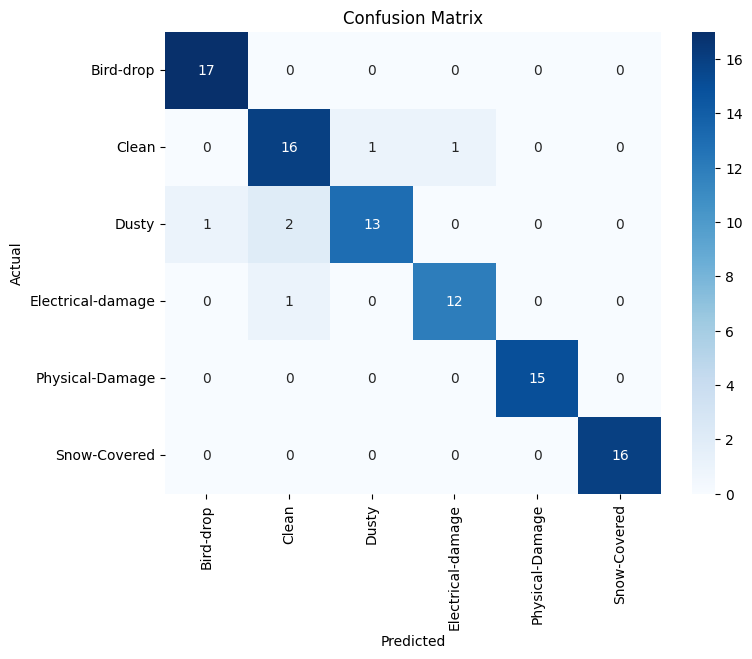

In [10]:
# STEP 7: Test Evaluation Metrics

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Classification report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=train_data.classes))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=train_data.classes,
            yticklabels=train_data.classes,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [11]:
# FIX: Install missing ONNX dependencies required by latest PyTorch

!pip install -q onnxscript


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.1/133.1 kB 13.3 MB/s eta 0:00:00


In [12]:
# STEP 8A: Export PyTorch model to ONNX

import torch

ONNX_PATH = "/content/solar_panel_defect_model.onnx"

# Dummy input (batch size 1, 3-channel, 224x224)
dummy_input = torch.randn(1, 3, 224, 224).to(DEVICE)

model.eval()

torch.onnx.export(
    model,
    dummy_input,
    ONNX_PATH,
    export_params=True,
    opset_version=11,
    do_constant_folding=True,
    input_names=["input_image"],
    output_names=["class_scores"],
    dynamic_axes={
        "input_image": {0: "batch_size"},
        "class_scores": {0: "batch_size"}
    }
)

print("✅ ONNX model exported to:", ONNX_PATH)


/tmp/ipython-input-3311461802.py:12: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W1218 21:15:42.026000 174 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 122, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

Applied 98 of general pattern rewrite rules.
✅ ONNX model exported to: /content/solar_panel_defect_model.onnx


In [13]:
# STEP 8B: Verify ONNX model inference

import onnxruntime as ort
import numpy as np

# Load ONNX model
ort_session = ort.InferenceSession(ONNX_PATH)

# Prepare dummy input
dummy_np = np.random.randn(1, 3, 224, 224).astype(np.float32)

# Run inference
outputs = ort_session.run(
    None,
    {"input_image": dummy_np}
)

print("ONNX output shape:", outputs[0].shape)
print("Sample output:", outputs[0])


ONNX output shape: (1, 6)
Sample output: [[  993.0995    199.42247  -608.0232  -2058.3643  -4874.3457  -1554.5675 ]]


In [14]:
# STEP G1: Install Gradio

!pip install -q gradio onnxruntime pillow


In [15]:
# STEP G2: Load ONNX model & preprocessing function

import onnxruntime as ort
import numpy as np
from PIL import Image
import torch
from torchvision import transforms

# Path to ONNX model
ONNX_PATH = "/content/solar_panel_defect_model.onnx"

# Load ONNX runtime session
ort_session = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])

print("✅ ONNX model loaded")

# Class labels (VERY IMPORTANT: order must match training)
CLASS_NAMES = [
    'Bird-drop',
    'Clean',
    'Dusty',
    'Electrical-damage',
    'Physical-Damage',
    'Snow-Covered'
]

# Same preprocessing as training
IMG_SIZE = 224

preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def predict_image(pil_image):
    """
    Input: PIL Image
    Output: (predicted_class, confidence, full_probs_dict)
    """
    img = preprocess(pil_image).unsqueeze(0).numpy().astype(np.float32)

    # ONNX inference
    outputs = ort_session.run(
        None,
        {"input_image": img}
    )[0]

    # Softmax
    exp_scores = np.exp(outputs)
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

    probs = probs[0]
    pred_idx = int(np.argmax(probs))

    predicted_class = CLASS_NAMES[pred_idx]
    confidence = float(probs[pred_idx])

    prob_dict = {CLASS_NAMES[i]: float(probs[i]) for i in range(len(CLASS_NAMES))}

    return predicted_class, confidence, prob_dict


print("✅ Inference pipeline ready")


✅ ONNX model loaded
✅ Inference pipeline ready


In [ ]:
# STEP G3: Gradio Interface

import gradio as gr

def gradio_predict(image):
    pred_class, confidence, prob_dict = predict_image(image)

    confidence_percent = f"{confidence * 100:.2f}%"

    return pred_class, confidence_percent, prob_dict


iface = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Image(type="pil", label="Upload Solar Panel Image (Thermal / IR / RGB)"),
    outputs=[
        gr.Textbox(label="Predicted Defect Class"),
        gr.Textbox(label="Confidence"),
        gr.Label(label="All Class Probabilities")
    ],
    title="AI-Powered Solar Panel Defect Detection",
    description=(
        "Upload any solar panel image (thermal, infrared, or RGB). "
        "The AI model classifies defects such as soiling, electrical damage, "
        "physical damage, snow coverage, or clean panels."
    ),
    examples=None
)

iface.launch(debug=True)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d55396fb96ea5bc795.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
